# レコード単位トレーニング・ノートブック

このノートブックでは、チェックポイントから学習済みモデルを読み込み、
**1レコード（1データサンプル）ずつ**トレーニングを実行できます。

## 機能
- チェックポイントからモデル読み込み
- 1レコード（単一のデータサンプル）ずつ実行
- トレーニング頻度の細かい調整
- リアルタイムでの可視化
- サンプルごとの詳細なログ

## 前提条件
- このノートブックは `notebooks/` ディレクトリから実行されます
- プロジェクトルートは `../` です
- `params.yaml` は `../params.yaml` にあります（自動的に読み込まれます）
- チェックポイントは `../checkpoint/CICIDS2017_improved/` にあります

## 1. セットアップ

In [1]:
import sys
import os

# プロジェクトルートをパスに追加
project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.insert(0, project_root)

# カレントディレクトリをプロジェクトルートに変更（params.yaml読み込みのため）
os.chdir(project_root)

import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import pandas as pd
from pathlib import Path
from IPython.display import clear_output, display
import time

# プロジェクトのモジュールをインポート
from train import get_command_line_parser, initialize_trainer
from utils import set_seed, set_gpu

# Jupyter用の設定
%matplotlib inline
%load_ext autoreload
%autoreload 2

plt.style.use('seaborn-v0_8-darkgrid')

print(f"Project root: {project_root}")
print(f"Current directory: {os.getcwd()}")
print(f"CUDA available: {torch.cuda.is_available()}")

Project root: /home/hawk/Documents/school/test/CVPR22-Fact
Current directory: /home/hawk/Documents/school/test/CVPR22-Fact
CUDA available: True


## 2. トレーナーの初期化

In [2]:
# コマンドライン引数を設定
parser = get_command_line_parser()
args = parser.parse_args([])

# シードを設定
set_seed(args.seed)

# トレーナーを初期化
print("Initializing trainer...")
trainer = initialize_trainer(args)

print(f"\n📊 Trainer Configuration:")
print(f"  Dataset: {trainer.args.dataset}")
print(f"  Encoder: {trainer.args.encoder}")
print(f"  Project: {trainer.args.project}")
print(f"  Base classes: {trainer.args.base_class}")
print(f"  Total classes: {trainer.args.num_classes}")
print(f"  Way: {trainer.args.way}")
print(f"  Shot: {trainer.args.shot}")
print(f"  Total sessions: {trainer.args.sessions}")
print(f"  New sessions: {list(range(1, trainer.args.sessions))}")

COMET WARNING: To get all data logged automatically, import comet_ml before the following modules: torch.
COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.


manual seed: 1
Initializing trainer...
manual seed: 1
{'alpha': 2.0,
 'balance': 0.01,
 'base_mode': 'ft_cos',
 'batch_size_base': 128,
 'batch_size_new': 0,
 'dataroot': 'data',
 'dataset': 'CICIDS2017_improved',
 'debug': False,
 'decay': 0.0005,
 'device': 'cuda',
 'encoder': 'cnn1d',
 'epochs_base': 10,
 'epochs_new': 100,
 'eta': 0.1,
 'gamma': 0.25,
 'gpu': '0',
 'loss_iter': 0,
 'lr_base': 0.005,
 'lr_new': 0.1,
 'milestones': [60, 70],
 'model_dir': None,
 'momentum': 0.9,
 'new_mode': 'avg_cos',
 'normalize_method': 'moving_minmax',
 'not_data_init': False,
 'num_workers': 8,
 'project': 'fact',
 'schedule': 'Cosine',
 'seed': 1,
 'select_sessions': [],
 'set_no_val': False,
 'shot': 3,
 'start_session': 0,
 'step': 20,
 'temperature': 32,
 'test_batch_size': 100,
 'use_wandb': False,
 'wandb_entity': '',
 'wandb_group': '',
 'wandb_mode': 'online',
 'wandb_project': 'origin-fact',
 'wandb_run_name': '',
 'wandb_tags': [],
 'wandb_watch': 'gradients',
 'wandb_watch_freq': 100}

COMET INFO: Experiment is live on comet.com https://www.comet.com/toshi/nids-on-fact/d9b6920a0add495f9b48d65644832299



use gpu: [0]
torch.Size([6, 128])
self.dummy_orthogonal_classifier.weight initialized over.
random init params

📊 Trainer Configuration:
  Dataset: CICIDS2017_improved
  Encoder: cnn1d
  Project: fact
  Base classes: 4
  Total classes: 10
  Way: 2
  Shot: 3
  Total sessions: 4
  New sessions: [1, 2, 3]


## 3. チェックポイントから読み込み

In [3]:
# 利用可能なチェックポイントを確認
# save_pathが相対パスの場合、絶対パスに変換
checkpoint_dir = Path(trainer.args.save_path)
if not checkpoint_dir.is_absolute():
    checkpoint_dir = Path(os.getcwd()) / checkpoint_dir

print(f"📁 Checkpoint directory: {checkpoint_dir}")
print(f"📁 Absolute path: {checkpoint_dir.absolute()}")
print(f"\nAvailable checkpoints:")

if checkpoint_dir.exists():
    checkpoints = sorted(checkpoint_dir.glob('*.pth'))
    for i, cp in enumerate(checkpoints):
        size_mb = cp.stat().st_size / (1024 * 1024)
        print(f"  [{i}] {cp.name} ({size_mb:.2f} MB)")
else:
    print(f"  ⚠ Directory not found. Please run base session training first.")

📁 Checkpoint directory: /home/hawk/Documents/school/test/CVPR22-Fact/checkpoint/CICIDS2017_improved
📁 Absolute path: /home/hawk/Documents/school/test/CVPR22-Fact/checkpoint/CICIDS2017_improved

Available checkpoints:
  [0] optimizer_best.pth (4.36 MB)
  [1] session0_max_acc.pth (4.38 MB)
  [2] session1_max_acc.pth (4.38 MB)
  [3] session2_max_acc.pth (4.38 MB)
  [4] session3_max_acc.pth (4.38 MB)
  [5] session4_max_acc.pth (4.38 MB)
  [6] session5_max_acc.pth (4.38 MB)
  [7] session6_max_acc.pth (4.38 MB)


In [4]:
# ベースセッションのチェックポイントを読み込み
base_checkpoint = checkpoint_dir / 'session0_max_acc.pth'

if base_checkpoint.exists():
    print(f"📥 Loading checkpoint: {base_checkpoint.name}")
    checkpoint = torch.load(base_checkpoint)
    
    # モデルの状態を復元
    trainer.model.load_state_dict(checkpoint['params'])
    
    print(f"\n✅ Checkpoint loaded successfully!")
    print(f"  Session: {checkpoint.get('session', 0)}")
    print(f"  Max accuracy: {checkpoint.get('max_acc', 'N/A')}")
    
    # ベースセッションのテスト
    print(f"\n🧪 Testing base session...")
    test_acc = trainer.test(trainer.model, 0, return_loss=False)
    print(f"  Base session accuracy: {test_acc:.4f}")
else:
    print(f"❌ Error: Checkpoint not found: {base_checkpoint}")
    print(f"Please run base session training first:")
    print(f"  dvc repro train_base")

📥 Loading checkpoint: session0_max_acc.pth

✅ Checkpoint loaded successfully!
  Session: 0
  Max accuracy: N/A

🧪 Testing base session...
[0 1 2 3]
[0 1 2 3]
[0 1 2 3]
[0 1 2 3]


100%|██████████| 3725/3725 [00:06<00:00, 567.48it/s]

epo 1, test, loss=0.0014 acc=0.9999, acc@5=1.0000
  Base session accuracy: 0.9999


## 4. トレーニングパラメータの設定

In [5]:
# トレーニングパラメータをカスタマイズ
training_config = {
    'target_session': 1,           # トレーニングするセッション
    'learning_rate': 0.1,          # 学習率
    'max_samples': 10000,          # 最大サンプル数
    'test_interval': 100,          # テスト実行間隔（サンプル）
    'log_interval': 50,            # ログ出力間隔（サンプル）
    'save_interval': 500,          # チェックポイント保存間隔
    'plot_update_interval': 100,   # グラフ更新間隔
}

print("⚙️ Training Configuration:")
for key, value in training_config.items():
    print(f"  {key}: {value}")

⚙️ Training Configuration:
  target_session: 1
  learning_rate: 0.1
  max_samples: 10000
  test_interval: 100
  log_interval: 50
  save_interval: 500
  plot_update_interval: 100


## 5. データローダーの準備

In [6]:
# 指定されたセッションのデータローダーを取得
session = training_config['target_session']

# カレントディレクトリを確実にプロジェクトルートに設定
import os
if not os.path.exists('params.yaml'):
    # params.yamlが見つからない場合はプロジェクトルートに移動
    os.chdir(project_root)
    print(f"⚠️ Changed directory to: {os.getcwd()}")

print(f"📍 Current working directory: {os.getcwd()}")

# セッションファイルの存在確認
session_file = f"data/index_list/CICIDS2017_improved/new_sessions/session_{session}.txt"
print(f"📄 Looking for: {session_file}")
print(f"📄 File exists: {os.path.exists(session_file)}")

print(f"\n📦 Loading data for session {session}...")
trainset, trainloader, testloader = trainer.get_dataloader(session)

# データセットのインデックスリストを作成
dataset_indices = list(range(len(trainset)))
current_idx = 0
current_epoch = 0

print(f"\n📊 Dataset info:")
print(f"  Training samples: {len(trainset)}")
print(f"  Test batches: {len(testloader)}")

# サンプルデータを確認
if hasattr(trainset, 'targets'):
    unique_classes = np.unique(trainset.targets)
    print(f"  Classes in this session: {unique_classes}")
    print(f"  Number of classes: {len(unique_classes)}")

# オプティマイザの初期化
print(f"\n🔧 Initializing optimizer...")
trainer.optimizer = torch.optim.SGD(
    trainer.model.parameters(),
    lr=training_config['learning_rate'],
    momentum=0.9,
    weight_decay=5e-4
)
trainer.criterion = torch.nn.CrossEntropyLoss()
print(f"  Optimizer: SGD")
print(f"  Learning rate: {training_config['learning_rate']}")

# ランダムシャッフル（エポックごとに実行）
np.random.shuffle(dataset_indices)
print(f"\n🔀 Dataset shuffled for epoch {current_epoch}")

📍 Current working directory: /home/hawk/Documents/school/test/CVPR22-Fact
📄 Looking for: data/index_list/CICIDS2017_improved/new_sessions/session_1.txt
📄 File exists: True

📦 Loading data for session 1...
[4 5]
[4 5]
[0 1 2 3 4 5]
[0 1 2 3 4 5]

📊 Dataset info:
  Training samples: 6
  Test batches: 3733
  Classes in this session: [4 5]
  Number of classes: 2

🔧 Initializing optimizer...
  Optimizer: SGD
  Learning rate: 0.1

🔀 Dataset shuffled for epoch 0


## 6. トレーニング履歴の初期化

In [7]:
# トレーニング履歴を記録
history = {
    'sample': [],
    'epoch': [],
    'loss': [],
    'prediction_correct': [],
    'test_acc': [],
    'learning_rate': [],
    'target_class': [],
    'predicted_class': [],
}

# 統計情報
stats = {
    'total_samples': 0,
    'correct_predictions': 0,
    'best_test_acc': 0.0,
    'best_sample': 0,
}

print("📝 Training history initialized")

📝 Training history initialized


## 7. 1レコードずつトレーニング（このセルを繰り返し実行）

**このセルを実行するたびに1サンプル分のトレーニングが進みます**

In [8]:
# 1サンプルのトレーニング
if stats['total_samples'] < training_config['max_samples']:
    # データセットの終端に達したか確認
    if current_idx >= len(dataset_indices):
        # エポック終了、新しいエポックを開始
        current_epoch += 1
        current_idx = 0
        np.random.shuffle(dataset_indices)
        print(f"\n🔄 Epoch {current_epoch} started (dataset reshuffled)")
    
    # 1サンプルを取得
    sample_idx = dataset_indices[current_idx]
    
    if trainer.args.dataset == 'CICIDS2017_improved':
        data, target = trainset[sample_idx]
    else:
        data, target = trainset[sample_idx][0], trainset[sample_idx][1]
    
    # バッチ次元を追加（モデルはバッチを期待するため）
    data = data.unsqueeze(0).cuda()  # [1, features]
    target = torch.tensor([target]).cuda()  # [1]
    
    # フォワードパス
    trainer.model.train()
    trainer.optimizer.zero_grad()
    output = trainer.model(data)
    
    # ロス計算
    loss = trainer.criterion(output, target)
    
    # バックワード
    loss.backward()
    trainer.optimizer.step()
    
    # 予測結果
    _, predicted = output.max(1)
    is_correct = predicted.eq(target).item()
    
    # 統計更新
    stats['total_samples'] += 1
    if is_correct:
        stats['correct_predictions'] += 1
    current_idx += 1
    
    # 履歴に記録
    history['sample'].append(stats['total_samples'])
    history['epoch'].append(current_epoch)
    history['loss'].append(loss.item())
    history['prediction_correct'].append(1 if is_correct else 0)
    history['learning_rate'].append(trainer.optimizer.param_groups[0]['lr'])
    history['target_class'].append(target.item())
    history['predicted_class'].append(predicted.item())
    
    # 現在の精度（移動平均）
    current_accuracy = stats['correct_predictions'] / stats['total_samples'] * 100
    
    # ログ出力
    if stats['total_samples'] % training_config['log_interval'] == 0 or stats['total_samples'] == 1:
        print(f"\n📊 Sample {stats['total_samples']} (Epoch {current_epoch}):")
        print(f"  Loss: {loss.item():.4f}")
        print(f"  Target class: {target.item()}, Predicted: {predicted.item()}")
        print(f"  Correct: {'✓' if is_correct else '✗'}")
        print(f"  Running accuracy: {current_accuracy:.2f}%")
    
    # テスト実行
    if stats['total_samples'] % training_config['test_interval'] == 0:
        print(f"\n🧪 Running test...")
        test_loss, test_acc = trainer.test(trainer.model, session, testloader, return_loss=True)
        history['test_acc'].append(test_acc)
        
        if test_acc > stats['best_test_acc']:
            stats['best_test_acc'] = test_acc
            stats['best_sample'] = stats['total_samples']
            print(f"  ✨ New best test accuracy: {test_acc:.4f}")
        else:
            print(f"  Test accuracy: {test_acc:.4f} (best: {stats['best_test_acc']:.4f})")
    
    # 簡易進捗表示
    progress = (stats['total_samples'] / training_config['max_samples']) * 100
    print(f"\n⏳ Progress: {progress:.1f}% ({stats['total_samples']}/{training_config['max_samples']} samples)")
    
else:
    print("\n✅ Training completed! Maximum samples reached.")
    print(f"  Total samples: {stats['total_samples']}")
    print(f"  Total epochs: {current_epoch}")
    print(f"  Overall accuracy: {stats['correct_predictions'] / stats['total_samples'] * 100:.2f}%")
    print(f"  Best test accuracy: {stats['best_test_acc']:.4f} (at sample {stats['best_sample']})")


📊 Sample 1 (Epoch 0):
  Loss: 32.1492
  Target class: 4, Predicted: 0
  Correct: ✗
  Running accuracy: 0.00%

⏳ Progress: 0.0% (1/10000 samples)


## 8. リアルタイム可視化

/tmp/ipykernel_55776/4023035561.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0, 0].legend()


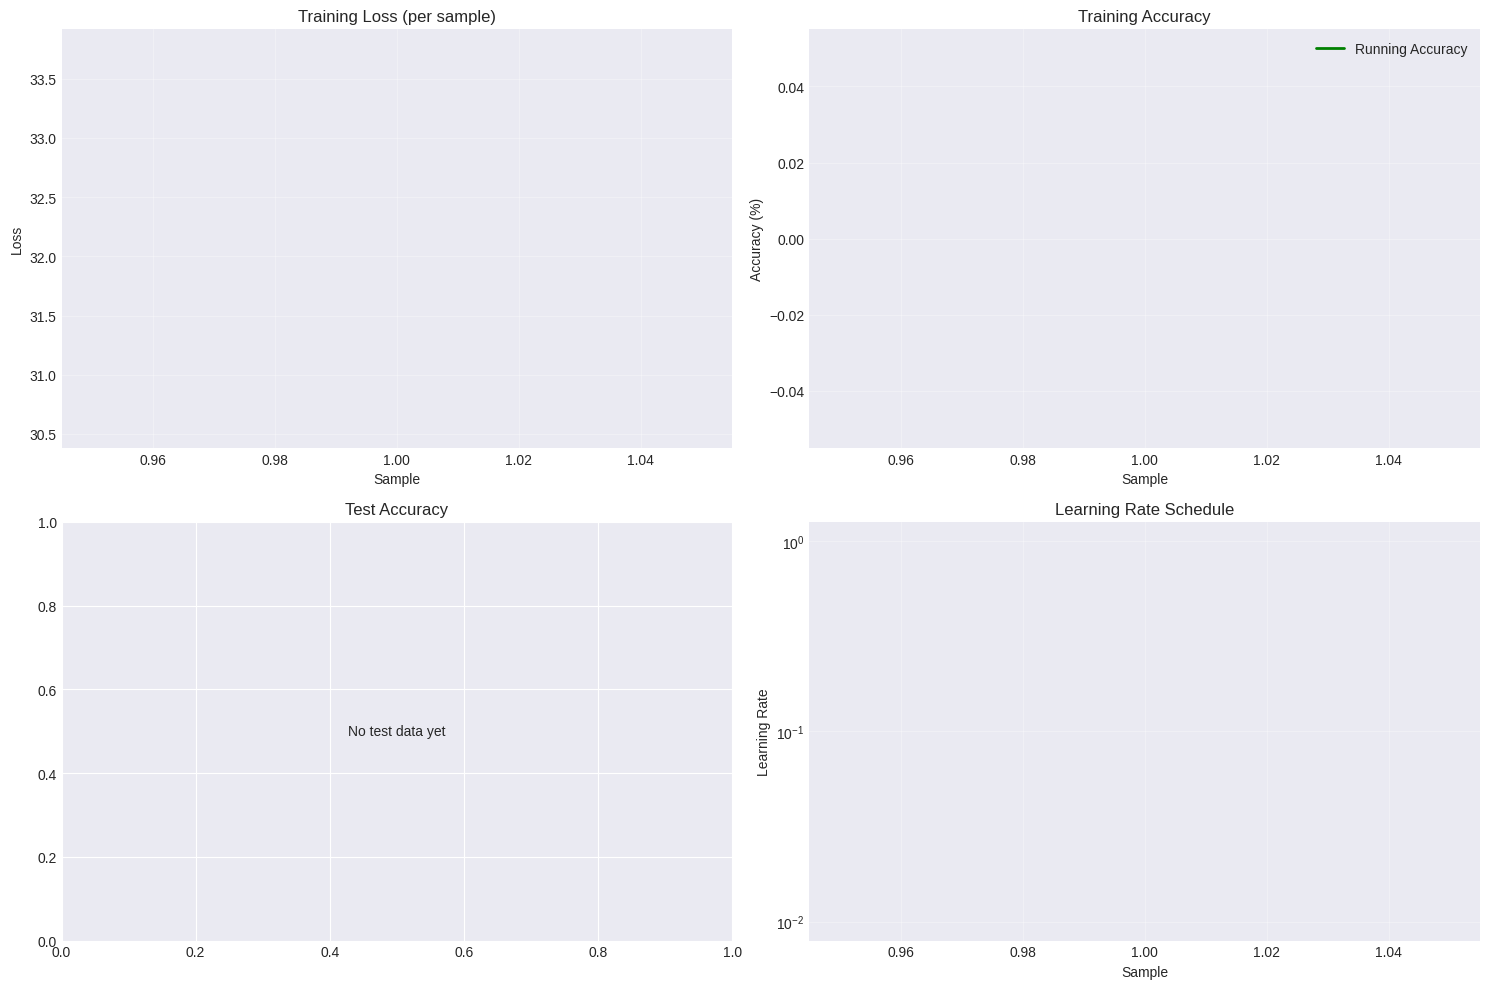


📈 Training Statistics:
  Total samples: 1
  Total epochs: 0
  Correct predictions: 0
  Overall accuracy: 0.00%
  Average loss (last 100): 32.1492


In [9]:
# トレーニング履歴を可視化
if len(history['sample']) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Loss
    axes[0, 0].plot(history['sample'], history['loss'], 'b-', alpha=0.3, linewidth=0.5)
    if len(history['loss']) > 50:
        # 移動平均を追加
        window = 50
        moving_avg = pd.Series(history['loss']).rolling(window=window).mean()
        axes[0, 0].plot(history['sample'], moving_avg, 'r-', linewidth=2, label=f'Moving Avg ({window})')
    axes[0, 0].set_xlabel('Sample')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].set_title('Training Loss (per sample)')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Prediction Accuracy (Running Average)
    if len(history['prediction_correct']) > 0:
        running_accuracy = np.cumsum(history['prediction_correct']) / np.arange(1, len(history['prediction_correct']) + 1) * 100
        axes[0, 1].plot(history['sample'], running_accuracy, 'g-', linewidth=2, label='Running Accuracy')
        if len(history['prediction_correct']) > 50:
            window = 50
            window_accuracy = pd.Series(history['prediction_correct']).rolling(window=window).mean() * 100
            axes[0, 1].plot(history['sample'], window_accuracy, 'b-', linewidth=1.5, alpha=0.7, 
                           label=f'Window Accuracy ({window})')
    axes[0, 1].set_xlabel('Sample')
    axes[0, 1].set_ylabel('Accuracy (%)')
    axes[0, 1].set_title('Training Accuracy')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # Test Accuracy
    if len(history['test_acc']) > 0:
        test_samples = [history['sample'][i] for i in range(0, len(history['sample']), training_config['test_interval']) 
                       if i < len(history['test_acc'])]
        test_samples = test_samples[:len(history['test_acc'])]
        axes[1, 0].plot(test_samples, [acc*100 for acc in history['test_acc']], 'ro-', 
                       linewidth=2, markersize=6)
        axes[1, 0].axhline(y=stats['best_test_acc']*100, color='g', linestyle='--', 
                          label=f"Best: {stats['best_test_acc']*100:.2f}%")
        axes[1, 0].set_xlabel('Sample')
        axes[1, 0].set_ylabel('Test Accuracy (%)')
        axes[1, 0].set_title('Test Accuracy')
        axes[1, 0].legend()
        axes[1, 0].grid(True, alpha=0.3)
    else:
        axes[1, 0].text(0.5, 0.5, 'No test data yet', ha='center', va='center')
        axes[1, 0].set_title('Test Accuracy')
    
    # Learning Rate
    axes[1, 1].plot(history['sample'], history['learning_rate'], 'purple', linewidth=2)
    axes[1, 1].set_xlabel('Sample')
    axes[1, 1].set_ylabel('Learning Rate')
    axes[1, 1].set_title('Learning Rate Schedule')
    axes[1, 1].grid(True, alpha=0.3)
    axes[1, 1].set_yscale('log')
    
    plt.tight_layout()
    plt.show()
    
    # 統計サマリー
    print(f"\n📈 Training Statistics:")
    print(f"  Total samples: {stats['total_samples']}")
    print(f"  Total epochs: {current_epoch}")
    print(f"  Correct predictions: {stats['correct_predictions']}")
    print(f"  Overall accuracy: {stats['correct_predictions'] / stats['total_samples'] * 100:.2f}%")
    print(f"  Average loss (last 100): {np.mean(history['loss'][-100:]):.4f}")
    if len(history['test_acc']) > 0:
        print(f"  Best test accuracy: {stats['best_test_acc']:.4f} (at sample {stats['best_sample']})")
        print(f"  Latest test accuracy: {history['test_acc'][-1]:.4f}")
else:
    print("No training history yet. Run the training cell above.")

## 9. 自動トレーニング（N サンプル実行）

複数サンプルを自動的に実行したい場合は、このセルを使用します。

In [10]:
# 自動実行の設定
auto_config = {
    'num_samples': 500,  # 実行するサンプル数
    'show_progress': True,  # プログレスバー表示
}

print(f"🚀 Running {auto_config['num_samples']} samples automatically...\n")

if auto_config['show_progress']:
    pbar = tqdm(range(auto_config['num_samples']), desc='Auto Training')
else:
    pbar = range(auto_config['num_samples'])

for _ in pbar:
    if stats['total_samples'] >= training_config['max_samples']:
        print("Maximum samples reached!")
        break
    
    # データセットの終端に達したか確認
    if current_idx >= len(dataset_indices):
        current_epoch += 1
        current_idx = 0
        np.random.shuffle(dataset_indices)
    
    # 1サンプルを取得
    sample_idx = dataset_indices[current_idx]
    
    if trainer.args.dataset == 'CICIDS2017_improved':
        data, target = trainset[sample_idx]
    else:
        data, target = trainset[sample_idx][0], trainset[sample_idx][1]
    
    # バッチ次元を追加
    data = data.unsqueeze(0).cuda()
    target = torch.tensor([target]).cuda()
    
    # トレーニング
    trainer.model.train()
    trainer.optimizer.zero_grad()
    output = trainer.model(data)
    loss = trainer.criterion(output, target)
    loss.backward()
    trainer.optimizer.step()
    
    # 予測結果
    _, predicted = output.max(1)
    is_correct = predicted.eq(target).item()
    
    # 統計更新
    stats['total_samples'] += 1
    if is_correct:
        stats['correct_predictions'] += 1
    current_idx += 1
    
    # 履歴に記録
    history['sample'].append(stats['total_samples'])
    history['epoch'].append(current_epoch)
    history['loss'].append(loss.item())
    history['prediction_correct'].append(1 if is_correct else 0)
    history['learning_rate'].append(trainer.optimizer.param_groups[0]['lr'])
    history['target_class'].append(target.item())
    history['predicted_class'].append(predicted.item())
    
    # テスト実行
    if stats['total_samples'] % training_config['test_interval'] == 0:
        test_loss, test_acc = trainer.test(trainer.model, session, testloader, return_loss=True)
        history['test_acc'].append(test_acc)
        
        if test_acc > stats['best_test_acc']:
            stats['best_test_acc'] = test_acc
            stats['best_sample'] = stats['total_samples']
    
    # プログレスバーの更新
    if auto_config['show_progress']:
        current_acc = stats['correct_predictions'] / stats['total_samples'] * 100
        pbar.set_postfix({
            'loss': f"{loss.item():.4f}",
            'acc': f"{current_acc:.1f}%",
            'best_test': f"{stats['best_test_acc']:.4f}"
        })

print(f"\n✅ Auto training completed!")
print(f"  Samples processed: {auto_config['num_samples']}")
print(f"  Total samples: {stats['total_samples']}")
print(f"  Overall accuracy: {stats['correct_predictions'] / stats['total_samples'] * 100:.2f}%")
print(f"  Best test accuracy: {stats['best_test_acc']:.4f}")

🚀 Running 500 samples automatically...



Auto Training:   0%|          | 0/500 [00:00<?, ?it/s]

100%|██████████| 3733/3733 [00:06<00:00, 599.98it/s]


epo 1, test, loss=37.4914 acc=0.0024, acc@5=0.1471


100%|██████████| 3733/3733 [00:06<00:00, 588.13it/s]


...

epo 1, test, loss=37.2673 acc=0.0024, acc@5=0.1488


100%|██████████| 3733/3733 [00:06<00:00, 593.60it/s]


epo 1, test, loss=37.3951 acc=0.0024, acc@5=0.1486


100%|██████████| 3733/3733 [00:06<00:00, 583.57it/s]

epo 1, test, loss=37.4972 acc=0.0024, acc@5=0.1486

✅ Auto training completed!
  Samples processed: 500
  Total samples: 501
  Overall accuracy: 97.21%
  Best test accuracy: 0.0024


## 10. チェックポイントの保存

In [11]:
# 現在のモデルをチェックポイントとして保存
save_path = checkpoint_dir / f'session{session}_notebook_sample{stats["total_samples"]}.pth'

checkpoint = {
    'session': session,
    'sample': stats['total_samples'],
    'epoch': current_epoch,
    'params': trainer.model.state_dict(),
    'optimizer': trainer.optimizer.state_dict(),
    'max_acc': stats['best_test_acc'],
    'history': history,
    'stats': stats,
}

torch.save(checkpoint, save_path)
print(f"💾 Checkpoint saved: {save_path.name}")
print(f"  Session: {session}")
print(f"  Samples: {stats['total_samples']}")
print(f"  Epochs: {current_epoch}")
print(f"  Overall accuracy: {stats['correct_predictions'] / stats['total_samples'] * 100:.2f}%")
print(f"  Best test accuracy: {stats['best_test_acc']:.4f}")

💾 Checkpoint saved: session1_notebook_sample501.pth
  Session: 1
  Samples: 501
  Epochs: 83
  Overall accuracy: 97.21%
  Best test accuracy: 0.0024


## 11. 詳細な履歴分析

In [12]:
# トレーニング履歴をDataFrameに変換
if len(history['sample']) > 0:
    df_history = pd.DataFrame({
        'sample': history['sample'],
        'epoch': history['epoch'],
        'loss': history['loss'],
        'correct': history['prediction_correct'],
        'target_class': history['target_class'],
        'predicted_class': history['predicted_class'],
        'lr': history['learning_rate'],
    })
    
    print("📊 Training History (last 20 samples):")
    print(df_history.tail(20).to_string(index=False))
    
    print(f"\n📈 Summary Statistics:")
    print(df_history[['loss', 'correct']].describe())
    
    # クラス別の精度
    print(f"\n🎯 Class-wise Accuracy:")
    class_accuracy = df_history.groupby('target_class')['correct'].agg(['sum', 'count', 'mean'])
    class_accuracy['accuracy_pct'] = class_accuracy['mean'] * 100
    print(class_accuracy)
    
    # エポックごとの統計
    if current_epoch > 0:
        print(f"\n📅 Epoch-wise Statistics:")
        epoch_stats = df_history.groupby('epoch').agg({
            'loss': ['mean', 'min', 'max'],
            'correct': ['sum', 'count', 'mean'],
            'sample': 'count'
        })
        print(epoch_stats)

📊 Training History (last 20 samples):
 sample  epoch         loss  correct  target_class  predicted_class  lr
    482     80 0.000000e+00        1             4                4 0.1
    483     80 0.000000e+00        1             5                5 0.1
    484     80 0.000000e+00        1             4                4 0.1
    485     80 0.000000e+00        1             5                5 0.1
    486     80 0.000000e+00        1             5                5 0.1
    487     81 0.000000e+00        1             5                5 0.1
    488     81 2.384186e-07        1             5                5 0.1
    489     81 0.000000e+00        1             5                5 0.1
    490     81 0.000000e+00        1             4                4 0.1
    491     81 0.000000e+00        1             4                4 0.1
    492     81 0.000000e+00        1             4                4 0.1
    493     82 0.000000e+00        1             5                5 0.1
    494     82 0.000000e+0

## 12. 現在のサンプルの詳細情報

In [13]:
# 最新のサンプル情報を表示
if len(history['sample']) > 0:
    print(f"🔍 Current Sample Information:")
    print(f"  Sample number: {stats['total_samples']}")
    print(f"  Current epoch: {current_epoch}")
    print(f"  Latest loss: {history['loss'][-1]:.4f}")
    print(f"  Latest prediction: {'✓ Correct' if history['prediction_correct'][-1] else '✗ Incorrect'}")
    print(f"  Target class: {history['target_class'][-1]}")
    print(f"  Predicted class: {history['predicted_class'][-1]}")
    print(f"  Current learning rate: {history['learning_rate'][-1]:.6f}")
    print(f"  Running accuracy: {stats['correct_predictions'] / stats['total_samples'] * 100:.2f}%")
    
    # 最近のトレンド
    if len(history['loss']) >= 50:
        recent_loss_trend = np.mean(history['loss'][-50:]) - np.mean(history['loss'][-100:-50]) if len(history['loss']) >= 100 else 0
        trend_symbol = "📉" if recent_loss_trend < 0 else "📈"
        print(f"\n  Loss trend (last 50 vs previous 50): {trend_symbol} {recent_loss_trend:+.4f}")
        
        recent_acc = np.mean(history['prediction_correct'][-50:]) * 100
        prev_acc = np.mean(history['prediction_correct'][-100:-50]) * 100 if len(history['prediction_correct']) >= 100 else 0
        acc_trend = recent_acc - prev_acc
        acc_symbol = "📈" if acc_trend > 0 else "📉"
        print(f"  Accuracy trend (last 50 vs previous 50): {acc_symbol} {acc_trend:+.2f}%")
    
    # 進捗
    progress_pct = (stats['total_samples'] / training_config['max_samples']) * 100
    remaining = training_config['max_samples'] - stats['total_samples']
    print(f"\n  Progress: {progress_pct:.1f}% ({remaining} samples remaining)")

🔍 Current Sample Information:
  Sample number: 501
  Current epoch: 83
  Latest loss: 0.0000
  Latest prediction: ✓ Correct
  Target class: 4
  Predicted class: 4
  Current learning rate: 0.100000
  Running accuracy: 97.21%

  Loss trend (last 50 vs previous 50): 📈 +0.0000
  Accuracy trend (last 50 vs previous 50): 📉 +0.00%

  Progress: 5.0% (9499 samples remaining)


## 13. 次のサンプルのプレビュー（トレーニングなし）

In [14]:
# 次のサンプルを確認（トレーニングは行わない）
if current_idx < len(dataset_indices):
    next_sample_idx = dataset_indices[current_idx]
    
    if trainer.args.dataset == 'CICIDS2017_improved':
        next_data, next_target = trainset[next_sample_idx]
    else:
        next_data, next_target = trainset[next_sample_idx][0], trainset[next_sample_idx][1]
    
    # 推論のみ
    trainer.model.eval()
    with torch.no_grad():
        next_data_batch = next_data.unsqueeze(0).cuda()
        next_output = trainer.model(next_data_batch)
        next_probs = F.softmax(next_output, dim=1)
        next_pred = next_output.argmax(dim=1).item()
        next_confidence = next_probs[0, next_pred].item()
    
    print(f"👀 Next Sample Preview (index {next_sample_idx}):")
    print(f"  True class: {next_target}")
    print(f"  Current prediction: {next_pred}")
    print(f"  Confidence: {next_confidence*100:.2f}%")
    print(f"  Will be {'✓ correct' if next_pred == next_target else '✗ incorrect'} if predicted now")
    
    # Top-3 predictions
    top3_probs, top3_classes = next_probs[0].topk(3)
    print(f"\n  Top-3 predictions:")
    for i, (prob, cls) in enumerate(zip(top3_probs, top3_classes)):
        marker = "★" if cls.item() == next_target else " "
        print(f"    {marker} Class {cls.item()}: {prob.item()*100:.2f}%")
else:
    print("📭 No more samples in current epoch. Run training cell to start next epoch.")

👀 Next Sample Preview (index 5):
  True class: 5
  Current prediction: 5
  Confidence: 100.00%
  Will be ✓ correct if predicted now

  Top-3 predictions:
    ★ Class 5: 100.00%
      Class 1: 0.00%
      Class 3: 0.00%
